In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

ghs_stat = pd.read_csv(
    "GHS_STAT_UCDB2015MT_GLOBE_R2019A_V1_2.csv",
    encoding='iso-8859-1'
)


cols = [
    'E_WR_T_90', 'E_WR_T_00', 'E_WR_T_14',
    'P90', 'P00', 'P15',
    'B90', 'B00', 'B15'
]

ghs_stat = ghs_stat[cols].copy()


# Convert all columns to numeric
ghs_stat = ghs_stat.apply(pd.to_numeric, errors='coerce')

# Replace infinite values with NaN
ghs_stat.replace([np.inf, -np.inf], np.nan, inplace=True)

# Remove missing values
ghs_stat.dropna(inplace=True)

# Remove rows where built-up area is zero
# (avoids division by zero errors)

ghs_stat = ghs_stat[
    (ghs_stat['B90'] > 0) &
    (ghs_stat['B00'] > 0) &
    (ghs_stat['B15'] > 0)
]

print(ghs_stat.shape)


ghs_stat['D90'] = ghs_stat['P90'] / ghs_stat['B90']
ghs_stat['D00'] = ghs_stat['P00'] / ghs_stat['B00']
ghs_stat['D15'] = ghs_stat['P15'] / ghs_stat['B15']


# Log transformation helps reduce skewness
# and makes patterns easier to visualise

ghs_stat['log_D90'] = np.log10(ghs_stat['D90'])
ghs_stat['log_D00'] = np.log10(ghs_stat['D00'])
ghs_stat['log_D15'] = np.log10(ghs_stat['D15'])

# Remove any infinite values created by log transform
ghs_stat.replace([np.inf, -np.inf], np.nan, inplace=True)
ghs_stat.dropna(inplace=True)


print(ghs_stat.head())

print("\nData Types:\n")
print(ghs_stat.dtypes)

print("\nMissing Values:\n")
print(ghs_stat.isnull().sum())

C:\Users\chrys\AppData\Local\Temp\ipykernel_21300\1771224084.py:7: DtypeWarning: Columns (9,10,13,14,15,16,17,18,19,26,27,28,29,30,31,32,33,34,35,36,45,46,47,53,54,55,56,57,58,59,63,67,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,123,124,125,126,127,128,129,130,153,154,155,156,157,159) have mixed types. Specify dtype option on import or set low_memory=False.
  ghs_stat = pd.read_csv(


(12869, 9)
   E_WR_T_90  E_WR_T_00  E_WR_T_14           P90           P00           P15  \
0  23.456032  23.153346  23.526622  378482.07210  458967.88170  512853.66670   
1  21.907134  22.041168  22.021633   71862.23154   83726.09207   91521.12460   
2  13.842484  13.216755  14.718191   95796.29582  114315.45190  123181.28480   
3  14.013689  13.865214  15.274110   57529.06097   65621.29096   67772.28886   
4  14.545047  13.866783  15.376907   89487.12828  106699.83780  114753.15020   

         B90        B00        B15          D90          D00          D15  \
0  78.845200  80.214867  80.647377  4800.318524  5721.730908  6359.210748   
1  14.051702  14.051702  14.493433  5114.130220  5958.430854  6314.661585   
2  37.215050  39.909760  42.000805  2574.127846  2864.348302  2932.831528   
3  25.807991  26.911415  27.759470  2229.118140  2438.418445  2441.411485   
4  33.175106  36.592659  38.101749  2697.418002  2915.880964  3011.755417   

    log_D90   log_D00   log_D15  
0  3.681270

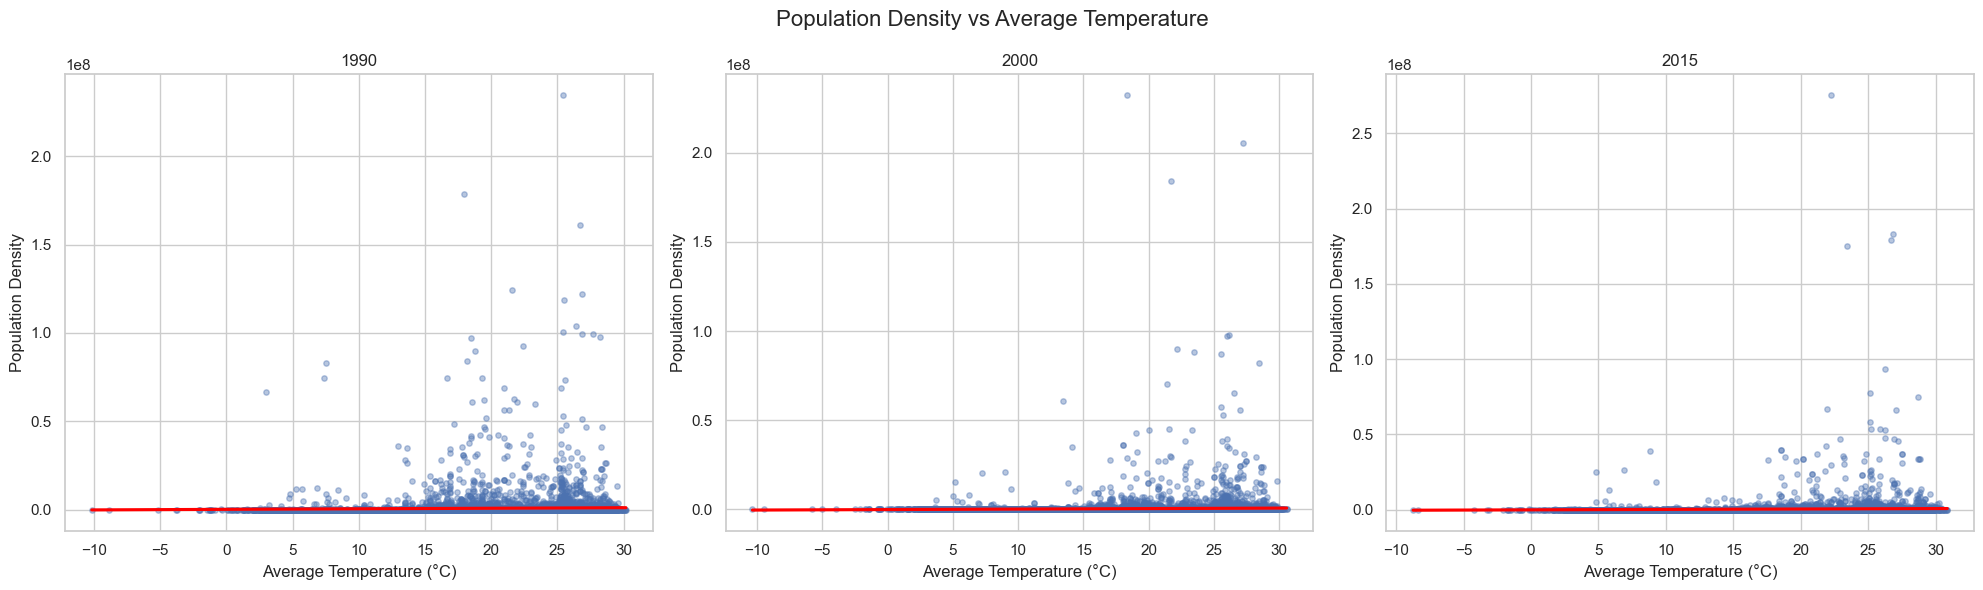

In [12]:
# ORIGINAL DENSITY VS TEMPERATURE

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

years = [
    ('E_WR_T_90', 'D90', '1990'),
    ('E_WR_T_00', 'D00', '2000'),
    ('E_WR_T_14', 'D15', '2015')
]

for ax, (temp, density, year) in zip(axes, years):

    sns.regplot(
        data=ghs_stat,
        x=temp,
        y=density,
        scatter_kws={
            'alpha': 0.4,
            's': 15
        },
        line_kws={
            'color': 'red'
        },
        ax=ax
    )

    ax.set_title(f'{year}')
    ax.set_xlabel('Average Temperature (°C)')
    ax.set_ylabel('Population Density')

plt.suptitle(
    'Population Density vs Average Temperature',
    fontsize=16
)

plt.tight_layout()
plt.show()

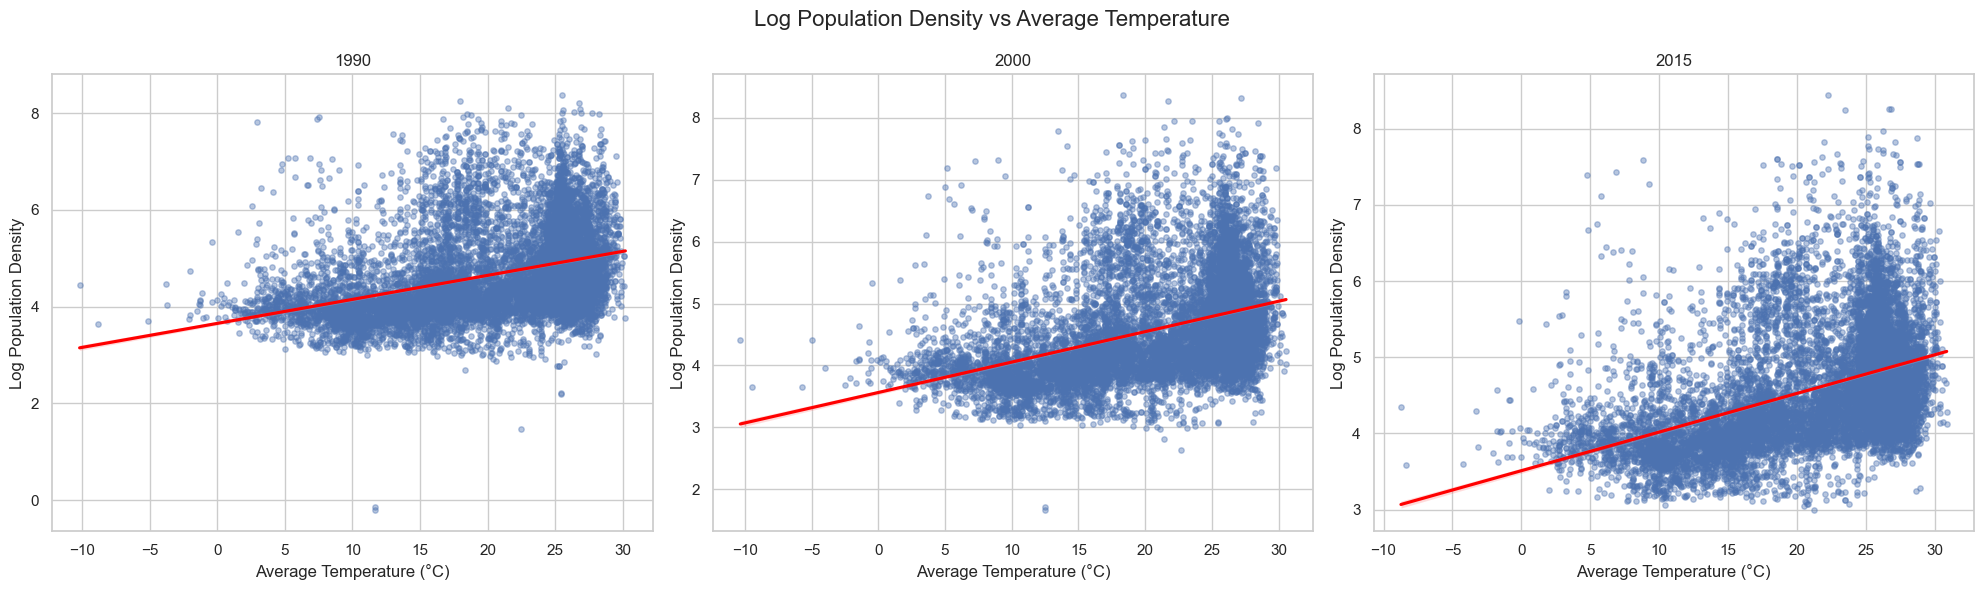

In [13]:
# LOG POPULATION DENSITY VS TEMPERATURE

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

log_years = [
    ('E_WR_T_90', 'log_D90', '1990'),
    ('E_WR_T_00', 'log_D00', '2000'),
    ('E_WR_T_14', 'log_D15', '2015')
]

for ax, (temp, density, year) in zip(axes, log_years):

    sns.regplot(
        data=ghs_stat,
        x=temp,
        y=density,
        scatter_kws={
            'alpha': 0.4,
            's': 15
        },
        line_kws={
            'color': 'red'
        },
        ax=ax
    )

    ax.set_title(f'{year}')
    ax.set_xlabel('Average Temperature (°C)')
    ax.set_ylabel('Log Population Density')

plt.suptitle(
    'Log Population Density vs Average Temperature',
    fontsize=16
)

plt.tight_layout()
plt.show()

In [14]:
# PEARSON CORRELATION ANALYSIS

print("PEARSON CORRELATION RESULTS")

for temp, density, year in years:

    r, p = pearsonr(
        ghs_stat[temp],
        ghs_stat[density]
    )

    print(f"{year}")
    print(f"Correlation coefficient (r): {r:.4f}")
    print(f"P-value: {p:.6f}")

    if p < 0.05:
        print("Result: Statistically significant")
    else:
        print("Result: Not statistically significant")

    print()


PEARSON CORRELATION RESULTS
1990
Correlation coefficient (r): 0.0366
P-value: 0.000032
Result: Statistically significant

2000
Correlation coefficient (r): 0.0407
P-value: 0.000004
Result: Statistically significant

2015
Correlation coefficient (r): 0.0406
P-value: 0.000004
Result: Statistically significant



In [15]:
# PEARSON CORRELATION ANALYSIS LOG DENSITIES

print("LOG DENSITY CORRELATION RESULTS")

for temp, density, year in log_years:

    r, p = pearsonr(
        ghs_stat[temp],
        ghs_stat[density]
    )

    print(f"{year}")
    print(f"Correlation coefficient (r): {r:.4f}")
    print(f"P-value: {p:.6f}")

    if p < 0.05:
        print("Result: Statistically significant")
    else:
        print("Result: Not statistically significant")

    print()

LOG DENSITY CORRELATION RESULTS
1990
Correlation coefficient (r): 0.3786
P-value: 0.000000
Result: Statistically significant

2000
Correlation coefficient (r): 0.4082
P-value: 0.000000
Result: Statistically significant

2015
Correlation coefficient (r): 0.4397
P-value: 0.000000
Result: Statistically significant




Shape of larger urban areas dataset:
(49, 15)


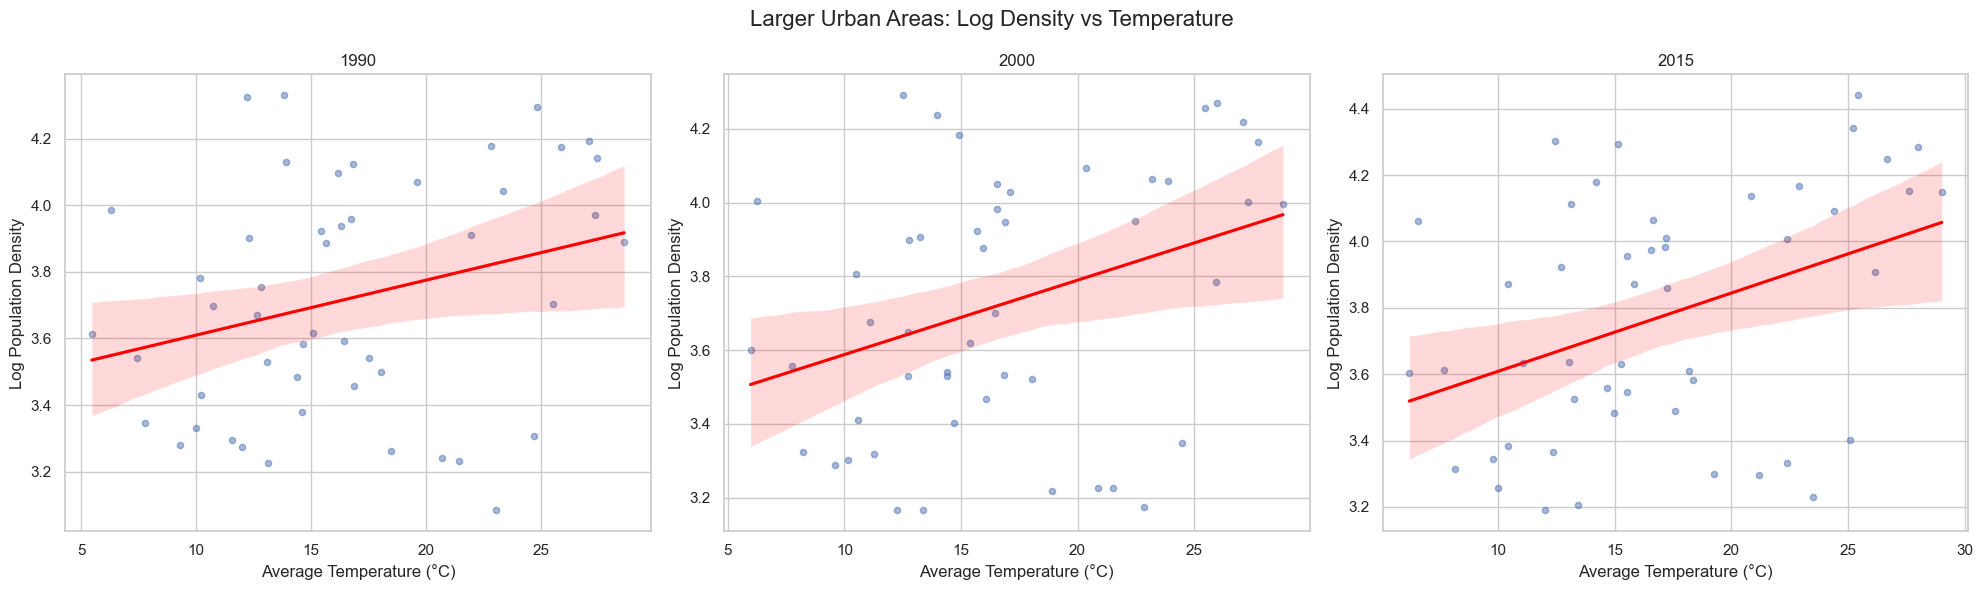

In [16]:
# ANALYSIS FOR LARGER BUILT-UP AREAS ONLY

ghs_stat2 = ghs_stat.copy()

# Keep only larger urban areas
ghs_stat2 = ghs_stat2[ghs_stat2['B15'] > 700]

print("\nShape of larger urban areas dataset:")
print(ghs_stat2.shape)

# PLOT FOR LARGER URBAN AREAS

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (temp, density, year) in zip(axes, log_years):

    sns.regplot(
        data=ghs_stat2,
        x=temp,
        y=density,
        scatter_kws={
            'alpha': 0.5,
            's': 20
        },
        line_kws={
            'color': 'red'
        },
        ax=ax
    )

    ax.set_title(f'{year}')
    ax.set_xlabel('Average Temperature (°C)')
    ax.set_ylabel('Log Population Density')

plt.suptitle(
    'Larger Urban Areas: Log Density vs Temperature',
    fontsize=16
)

plt.tight_layout()
plt.show()

In [17]:
# CORRELATION FOR LARGER URBAN AREAS

print("LARGER URBAN AREAS RESULTS")

for temp, density, year in log_years:

    r, p = pearsonr(
        ghs_stat2[temp],
        ghs_stat2[density]
    )

    print(f"{year}")
    print(f"Correlation coefficient (r): {r:.4f}")
    print(f"P-value: {p:.6f}")

    if p < 0.05:
        print("Result: Statistically significant")
    else:
        print("Result: Not statistically significant")

    print()

LARGER URBAN AREAS RESULTS
1990
Correlation coefficient (r): 0.2862
P-value: 0.046205
Result: Statistically significant

2000
Correlation coefficient (r): 0.3476
P-value: 0.014385
Result: Statistically significant

2015
Correlation coefficient (r): 0.3917
P-value: 0.005379
Result: Statistically significant



Scatter plots and Pearson correlation analysis were used to examine the relationship between population density and average temperature in urban areas for 1990, 2000 and 2015. The plots showed a weak positive relationship across all three years, meaning that areas with higher temperatures tended to have slightly higher population densities. However, the data points were widely spread out, suggesting that the relationship is not particularly strong. A number of highly populated cities also appeared as outliers, highlighting large differences between urban areas around the world.

The Pearson correlation coefficients were relatively low, indicating that average temperature alone is not a strong predictor of population density. Despite this, some of the p-values showed statistical significance, likely because of the large size of the dataset. The trend lines followed a similar pattern in all three years, suggesting that the relationship between temperature and population density remained fairly consistent over time.

Overall, the analysis suggests there may be a small association between warmer climates and higher urban population density, but the relationship is weak and is likely influenced by many other factors such as economic development, geography and infrastructure.